# CNN
- Convolution(합성곱)
  - 필터(커널)를 입력 이미지에 sliding 하면서
국소 영역을 linear combination → feature map 생성

- Filter(kernel)
  - 크기: (Kh × Kw)
  - 여러 개 있으면 각 필터마다 독립된 feature map 생성 → depth 증가
  - filter들의 weight값은 training 과정을 거쳐 fitting된다.

- Feature map
  - 컨볼루션 결과로 나온 출력
  - 필터가 무엇을 학습했는지 표현 (edge, texture, pattern 등)

- Stride
  - 필터가 한 번에 움직이는 거리
  - 세로 stride = Sh, 가로 stride = Sw

- Padding
  - 입력 주변에 값을 채워넣는 작업
  - 주로 zero padding 사용
  - 목적: 출력 크기 유지 (SAME padding)
  - 특정 위치 패턴을 더 잘 학습하도록 중심화

- Pooling
  - 공간 크기(H×W)를 줄이면서 중요한 정보 유지
  - 종류
    - Max Pooling
    - Avg Pooling

## Feature map 크기 공식
- 입력 크기: 𝐻 × 𝑊
- 필터 크기: 𝐾ℎ × 𝐾𝑤
- Padding: 𝑃ℎ , 𝑃𝑤
- Stride: 𝑆ℎ , 𝑆𝑤
- 출력 크기 공식 (소수점 나오면 1 더하기 전에 버림 후 계산. 만약 풀링 계산이라면 풀링 크기를 필터 크기로 생각하고 계산하면 된다. (즉, 필터 크기 공식에 풀링 크기를 대입))
  - 𝐻 = [ ( 𝐻 - 𝐾ℎ + 2𝑃ℎ ) / 𝑆 ] + 1
  - 𝑊 = [ ( 𝑊 - 𝐾𝑤 + 2𝑃𝑤 ) / 𝑆 ] + 1

- (출력 크기 == 입력크기)인 padding 계산 공식
  - 𝑃ℎ = [ (𝑆ℎ*(𝐻 - 1) - 𝐻 + 𝐾ℎ) / 2 ]
  - 𝑃𝑤 = [ (𝑆𝑤*(𝑊 - 1) - 𝑊 + 𝐾𝑤) / 2 ]

---

# 1. CNN(Convolutional Neural Network)의 기본 개념

* 이미지·영상·음성 등 상호 구조가 있는 데이터(Spatial/Temporal Structure)를 처리하기 위한 신경망.
* **인간 시각피질(V1 영역) 모델링**에서 출발.
* 합성곱(Convolution) 연산을 기반으로 특징을 추출하며, 지역적 패턴(Edge, Texture, Shape)을 자동 학습.
* 응용 분야: 이미지 분류, 객체 탐지, 자율주행, 음성 인식, 자연어 처리 등.

---

# 2. Convolution Layer의 핵심 원리

## (1) 지역 연결(Local Receptive Field)

* Dense layer는 모든 입력과 연결되지만,
* Convolution layer의 뉴런은 입력 전체가 아니라 일부 영역(예: 3×3 패치)만 본다.

## (2) Window / Filter / Kernel

* 3×3, 5×5와 같은 작은 크기의 창(window)이 입력 위를 sliding 하며 연산.
* 하나의 필터는 하나의 특징(feature)을 감지.
* 필터 × 입력 → **Feature Map(Activation Map)** 생성.

## (3) Convolution 계산 방식

* 필터와 입력의 같은 위치 픽셀끼리 곱한 후 모두 합산 → 단일 스칼라 출력.
* 이 과정을 윈도우가 이동할 때마다 반복하여 하나의 Feature Map 형성.

---

# 3. 여러 개의 필터 사용

* 필터를 여러 개 두면 **여러 종류의 특징**을 병렬로 추출 가능.
* 예: 필터 8개 → feature map 8개 → 출력 텐서 shape = (H’, W’, 8)

---

# 4. Bias

* Dense layer와 동일하게 **각 필터마다 bias 1개**가 존재.
* Feature map 전체에 **동일한 상수**가 더해짐.

---

# 5. 채널(Channel)과 필터 구조

## (1) 입력 채널이 여러 개인 경우 (RGB 등)

* 입력: (H, W, C)
* 하나의 필터는 **각 채널마다 별도의 커널**을 가짐.
* 채널별 컨볼루션 결과를 모두 더해 **하나의 feature map** 생성.

예:
입력 채널 3개, 필터 1개 → 필터 내부 커널도 3개
(3×3×3 구조)

## (2) 여러 필터를 쓰면?

* 필터 K개 → K개의 feature map → 출력 채널 = K

---

# 6. 출력 텐서의 구조 (특성맵 = 채널)
```
출력 shape
[
(batch,; H',; W',; filters)
]
filters = 출력 채널의 개수 = feature map의 개수
```
---

# 7. 패딩(Padding)

## 필요성

* 필터를 적용하면 출력 크기가 줄어든다.
  예: 28×28 → (3×3 필터) → 26×26

## Zero Padding

* 입력 주변을 0으로 채워 **크기 유지 또는 감소 방지**
* Keras: `padding="same"`

---

# 8. 스트라이드(Stride)

* 윈도우가 이동하는 간격
  (stride=2면 2칸씩 이동하여 출력 크기가 절반으로 줄어듦)
* 계산량·메모리 감소 목적.

---

# 9. 풀링(Pooling Layer)

## 목적

* 공간 크기(H×W)를 줄여 **계산량 감소·과적합 방지**
* 지역 정보 요약(translation invariance 제공)

## 종류

* Max Pooling: 구역 내 최대값
* Average Pooling: 구역 내 평균값

## 특징

* **학습 파라미터가 없음(비학습 연산)**

---

# 10. CNN의 전형적 구조

일반적 순서:

1. Conv → ReLU
2. Conv → ReLU
3. Pooling
4. Conv → ReLU
5. Pooling
6. Flatten
7. Fully-connected layer (Dense)
8. Softmax

특징:

* **깊어질수록 공간 크기↓, 채널(특성맵) 수↑**
* 고수준 특징(Shape, Object Structure)을 말단에서 학습

---

# 11. 대표 CNN 아키텍처

### ■ LeNet-5 (1998)

* 초기 CNN 모델, 손글씨 인식 성공.

### ■ AlexNet (2012)

* GPU 학습 본격화, 8층 구조.
* ReLU, Dropout, Data Augmentation 도입.
* 60M 파라미터.

### ■ GoogLeNet / Inception (2014)

* 22층이지만 파라미터는 7M으로 매우 적음.
* **Inception module**로 병렬 필터 구조 도입.

### ■ ResNet (2015)

* **Residual Connection(Shortcut)** 등장.
* 깊이가 매우 깊어져도 gradient vanishing 극복.
* 모델 안정성 최고 수준으로 향상.

---

# 데이터 로드 및 준비

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 데이터셋: "mnist"
dataset = "mnist"

if dataset == "mnist":
    (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
else:
    (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

print(train_images.shape, test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1) (10000, 28, 28, 1)


# 합성곱 필터가 강조하는 특징 시각화
(1) 직접 만든 필터로 특징 추출해 보기
- 수직선 / 수평선을 감지하는 필터 생성

In [ ]:
# Conv2D 레이어 생성
model = models.Sequential([
    layers.Conv2D(filters=2, kernel_size=(3,3), input_shape=(28,28,1), padding='same', use_bias=False)
])

# 사용자 정의 필터 (3x3)
vertical_filter = np.array([[1, -1, 1],
                            [1, -1, 1],
                            [1, -1, 1]], dtype=np.float32)

horizontal_filter = np.array([[1, 1, 1],
                              [-1,-1,-1],
                              [1, 1, 1]], dtype=np.float32)

# (3,3,1,필터수) 형태로 변환
filters = np.zeros((3,3,1,2), dtype=np.float32)
filters[:,:,0,0] = vertical_filter
filters[:,:,0,1] = horizontal_filter

# 필터 설정
model.layers[0].set_weights([filters])
print(model.layers[0].get_weights()[0].shape)

(3, 3, 1, 2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(2) 필터를 이미지에 적용하여 특성맵 시각화

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


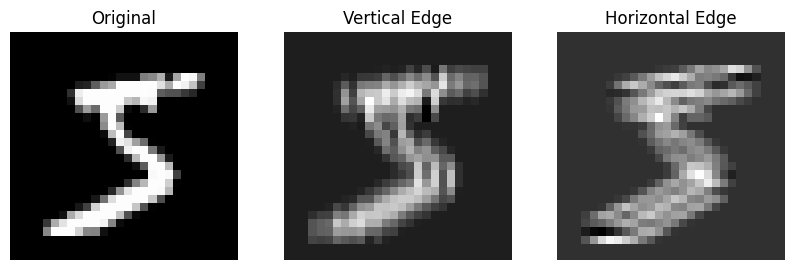

In [ ]:
# 샘플 이미지 선택
sample = train_images[0:1]

# 합성곱 결과
feature_maps = model.predict(sample)

# 시각화
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(sample[0].reshape(28,28), cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Vertical Edge")
plt.imshow(feature_maps[0,:,:,0], cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Horizontal Edge")
plt.imshow(feature_maps[0,:,:,1], cmap='gray')
plt.axis("off")

plt.show()

# 실제 CNN을 만들고 학습된 필터 시각화하기

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D(2),ㄴ
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2),
])

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

(1) CNN 학습

In [ ]:
cnn.add(layers.Flatten())
cnn.add(layers.Dense(128, activation='relu'))
cnn.add(layers.Dense(10, activation='softmax'))

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.fit(train_images, train_labels, epochs=3, batch_size=64)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 67ms/step - accuracy: 0.8965 - loss: 0.3413
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.9861 - loss: 0.0442
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.9907 - loss: 0.0301


(2) 1번째 합성곱층의 필터 시각화

(3, 3, 1, 32)


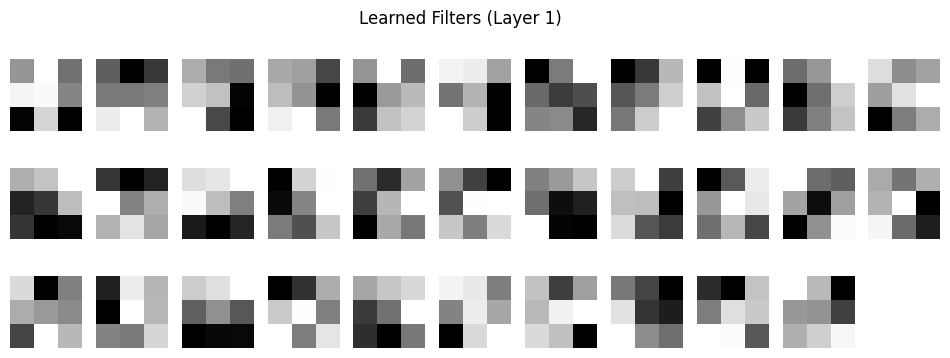

In [ ]:
filters, biases = cnn.layers[0].get_weights()
print(filters.shape)  # (3,3,1,32)

# 32개의 필터를 시각화
num_filters = filters.shape[3]

plt.figure(figsize=(12,4))
for i in range(num_filters):
    f = filters[:,: ,0,i]  # (3,3)
    plt.subplot(3,11,i+1)
    plt.imshow(f, cmap='gray')
    plt.axis("off")

plt.suptitle("Learned Filters (Layer 1)")
plt.show()

(3) 학습된 필터가 만들어내는 Feature Map 시각화

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
(1, 28, 28, 32)


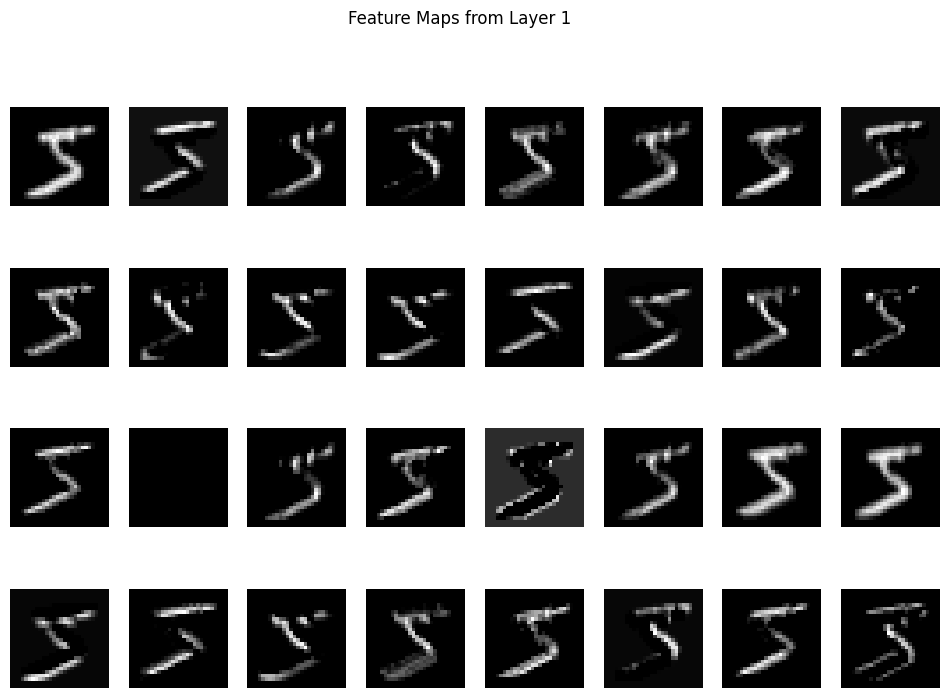

In [ ]:
from tensorflow.keras import models

# 중간 레이어 출력 모델 생성
layer_outputs = [layer.output for layer in cnn.layers[:4]]
activation_model = models.Model(inputs=cnn.layers[0].input, outputs=layer_outputs)

sample = train_images[0:1]
activations = activation_model.predict(sample)

# 첫 Conv layer feature map
first_layer_activation = activations[0]
print(first_layer_activation.shape)  # (1,28,28,32)

plt.figure(figsize=(12,8))
for i in range(32):
    plt.subplot(4,8,i+1)
    plt.imshow(first_layer_activation[0,:,:,i], cmap='gray')
    plt.axis("off")

plt.suptitle("Feature Maps from Layer 1")
plt.show()